In [1]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [12]:
from sklearn.datasets import fetch_california_housing

In [16]:
boston = fetch_california_housing(as_frame=True)

In [18]:
X = boston['data']

In [20]:
X.shape

(20640, 8)

#### Step 1

In [23]:
mu = X.mean(axis=0)
# mean centering
X_ = (X - mu)
X_.shape

(20640, 8)

#### Step 2

In [26]:
S = np.dot(X_.T, X_)
S.shape

(8, 8)

#### Step 3

In [28]:
lambdas, vectors = np.linalg.eig(S)

In [29]:
lambdas.shape

(8,)

In [30]:
lambdas[:2]

array([2.64692082e+10, 2.99909311e+06])

In [31]:
vectors.shape

(8, 8)

#### Step 4

In [33]:
V = vectors[:, :2]
V.shape

(8, 2)

#### Step 5 Projection

In [36]:
X_.shape

(20640, 8)

In [37]:
V.shape

(8, 2)

In [38]:
X_new = np.dot(X_, V)
X_new.shape

(20640, 2)

In [39]:
X_new

array([[1103.51264821,    8.56663624],
       [-975.54124442,   -4.67041774],
       [ 929.54990812,   20.03465092],
       ...,
       [ 418.43757543,  -12.90825582],
       [ 684.43952537,  -12.79458051],
       [  38.43624736,  -12.67037806]])

In [40]:
total = sum(lambdas)

In [41]:
explained_variance = np.round(lambdas/total, 3)
explained_variance

array([1., 0., 0., 0., 0., 0., 0., 0.])

In [42]:
explained_variance[:2].sum()

1.0

In [43]:
explained_variance

array([1., 0., 0., 0., 0., 0., 0., 0.])

In [57]:
cummulative_variance =  np.cumsum(explained_variance)
cummulative_variance

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [59]:
import matplotlib.pyplot as plt

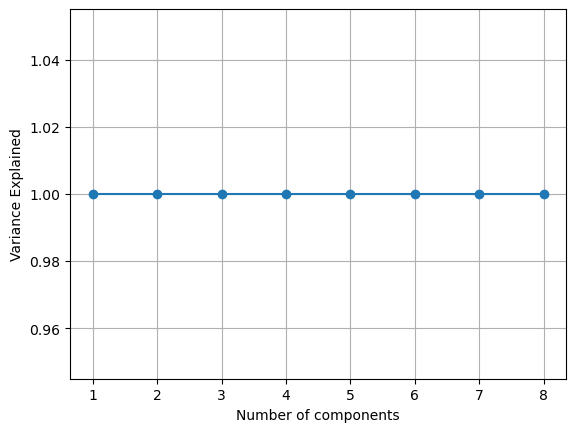

In [60]:
plt.plot( range(1, len(cummulative_variance)+1) , cummulative_variance, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Variance Explained")
plt.grid("on")

## Sklearn

In [66]:
from sklearn.decomposition import PCA

In [67]:
pca = PCA(n_components=2)

In [70]:
pca.fit_transform(X)

array([[-1103.51264821,     8.56663624],
       [  975.54124442,    -4.67041774],
       [ -929.54990812,    20.03465092],
       ...,
       [ -418.43757543,   -12.90825582],
       [ -684.43952537,   -12.79458051],
       [  -38.43624736,   -12.67037806]])

In [72]:
pca.explained_variance_ratio_

array([9.99789327e-01, 1.13281110e-04])

In [74]:
pca.explained_variance_ratio_.sum()

0.9999026078862244